# MIMIC-III Demo — Initial EDA

Sanity-checks the raw tables pulled by `data/download_mimic_demo.py` before any feature engineering happens. This notebook does **not** decide the 30-day readmission label logic — that belongs to step 2 — it only surfaces the raw signal and the open questions.

Note: this demo release (v1.4) uses lowercase column names (`subject_id`, `admittime`, ...), unlike older MIMIC-III docs/examples that show uppercase.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("../data/raw")

## Load tables

In [2]:
admissions = pd.read_csv(DATA_DIR / "ADMISSIONS.csv", parse_dates=["admittime", "dischtime", "deathtime"])
patients = pd.read_csv(DATA_DIR / "PATIENTS.csv")
diagnoses = pd.read_csv(DATA_DIR / "DIAGNOSES_ICD.csv")
labevents = pd.read_csv(DATA_DIR / "LABEVENTS.csv")
noteevents = pd.read_csv(DATA_DIR / "NOTEEVENTS.csv")
icustays = pd.read_csv(DATA_DIR / "ICUSTAYS.csv")

## Row counts & basic shape

In [3]:
tables = {
    "ADMISSIONS": admissions,
    "PATIENTS": patients,
    "DIAGNOSES_ICD": diagnoses,
    "LABEVENTS": labevents,
    "NOTEEVENTS": noteevents,
    "ICUSTAYS": icustays,
}
for name, df in tables.items():
    print(f"{name:15s} {len(df):>8,} rows  {df.shape[1]:>3} cols")

ADMISSIONS           129 rows   19 cols
PATIENTS             100 rows    8 cols
DIAGNOSES_ICD      1,761 rows    5 cols
LABEVENTS         76,074 rows    9 cols
NOTEEVENTS             0 rows   11 cols
ICUSTAYS             136 rows   12 cols


In [4]:
print("distinct subject_id (patients):", admissions["subject_id"].nunique())
print("distinct hadm_id (admissions): ", admissions["hadm_id"].nunique())
print("admission date range:", admissions["admittime"].min(), "to", admissions["admittime"].max())
admissions.isnull().sum()

distinct subject_id (patients): 100
distinct hadm_id (admissions):  129
admission date range: 2102-08-29 07:15:00 to 2202-10-03 01:45:00


row_id                   0
subject_id               0
hadm_id                  0
admittime                0
dischtime                0
deathtime               89
admission_type           0
admission_location       0
discharge_location       0
insurance                0
language                48
religion                 1
marital_status          16
ethnicity                0
edregtime               37
edouttime               37
diagnosis                0
hospital_expire_flag     0
has_chartevents_data     0
dtype: int64

## NOTEEVENTS — known limitation of the demo dataset

PhysioNet strips discharge-summary text from the **demo** release. The full text only exists in the credentialed MIMIC-III database. This is expected — but it's a real blocker for the project's planned text/SLM path (step 3), which needs to be decided before that step: either apply for full MIMIC-III credentialed access, or rescope the text path.

In [5]:
print(f"NOTEEVENTS row count: {len(noteevents)}")
if len(noteevents) == 0:
    print("CONFIRMED: no note text available in this demo dataset.")

NOTEEVENTS row count: 0
CONFIRMED: no note text available in this demo dataset.


## Readmission signal — exploratory only

MIMIC-III's `ADMISSIONS` table has no readmission column. Here we just look at the raw gap, per patient, between one discharge and their next admission — purely to see the shape of the signal. This is **not** the final label definition.

count     29.000000
mean      69.775742
std       83.093967
min        1.613194
25%       11.275000
50%       45.994444
75%       83.372222
max      396.298611
Name: gap_days, dtype: float64


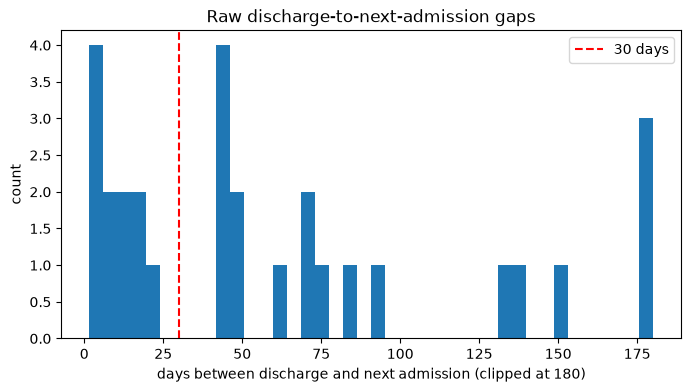

In [6]:
adm_sorted = admissions.sort_values(["subject_id", "admittime"]).copy()
adm_sorted["next_admittime"] = adm_sorted.groupby("subject_id")["admittime"].shift(-1)
adm_sorted["gap_days"] = (adm_sorted["next_admittime"] - adm_sorted["dischtime"]).dt.total_seconds() / 86400

gaps = adm_sorted["gap_days"].dropna()
print(gaps.describe())

plt.figure(figsize=(8, 4))
plt.hist(gaps.clip(upper=180), bins=40)
plt.axvline(30, color="red", linestyle="--", label="30 days")
plt.xlabel("days between discharge and next admission (clipped at 180)")
plt.ylabel("count")
plt.legend()
plt.title("Raw discharge-to-next-admission gaps")
plt.show()

### Open design questions for step 2 (not decided here)

- **Windowing threshold**: 30 days from discharge, as above — but from discharge or from the prior admission's start?
- **Elective/newborn exclusions**: should `admission_type == 'ELECTIVE'` or newborn admissions be excluded from being counted as a "readmission" event?
- **Deaths**: patients with a `deathtime` set (or `hospital_expire_flag`) can't be readmitted — how should the label / eligible population handle this?
- **Transfers**: does a transfer between services count as a separate admission for this purpose?

## Diagnoses sanity check

In [7]:
diagnoses["icd9_code"].value_counts().head(15)

icd9_code
4019     53
42731    48
5849     45
4280     39
25000    31
51881    31
2724     29
5990     27
486      26
99592    25
2859     25
0389     24
2449     23
41401    18
V5861    18
Name: count, dtype: int64

## Labs sanity check

In [8]:
print(f"LABEVENTS row count: {len(labevents):,}")
print(f"distinct itemid: {labevents['itemid'].nunique()}")

LABEVENTS row count: 76,074
distinct itemid: 439
